In [1]:
# system imports
import re
from pathlib import Path

# torch imports
import torch
from lightning import LightningModule, Trainer
from lightning.pytorch.callbacks import EarlyStopping

# project imports 
from core.models import DeepReLUClassifier 
from core.data import MNISTLightningDataModule 
from core.bias import RidgeBias 
from core.estimators import BiasWithCrossEntropy 
from core.wandb_utils import wandb_summary_df

# wandb imports
import wandb
import pandas as pd

# data visualization imports
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from core.plotting import panelplot
plt.style.use("../clean_fig.mplstyle")


## Access previous runs

In [ ]:
api = wandb.Api(timeout=60)
user_org = "<wandb-entity>"
project_name = "inductive-bias"
sweep_id = "2stzqc65"
sweep = api.sweep(f"{user_org}/{project_name}/{sweep_id}")
runs = sweep.runs  # automatically filtered to that sweep

def download_checkpoint(run, alias="best"):  # alias "latest" or explicit step also works
    artifacts = run.logged_artifacts()
    model_artifacts = [a for a in artifacts if a.type == "model"]
    # pick the latest matching alias
    for artifact in sorted(model_artifacts, key=lambda a: a.created_at, reverse=True):
        if alias in artifact.aliases:
            artifact_dir = artifact.download()
            # Lightning checkpoints are usually named `model.ckpt`
            return Path(artifact_dir) / "model.ckpt"
    raise FileNotFoundError(f"No checkpoint with alias '{alias}' for run {run.name}")

def load_model_from_run(run):
    cfg = run.config
    print(cfg)
    model = DeepReLUClassifier(
        input_dim=28*28,
        width=cfg["width"],
        depth=cfg["depth"],
        dropout=cfg["dropout"],
        batchnorm=cfg["batchnorm"],
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        l2_penalty=cfg["l2_penalty"],
    )
    ckpt_path = download_checkpoint(run, alias="best")  # or "latest"
    state_dict = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state_dict["state_dict"])
    model.eval()
    return model

In [ ]:
def fit_bias_for_run(run):
    model = load_model_from_run(run)
    # Build whichever bias model(s) you want
    bias_model = RidgeBias()
    estimator = BiasWithCrossEntropy(
        predictive_model=model.eval(),
        bias_model=bias_model,
    )
    dm = MNISTLightningDataModule(root="~/inductive-bias/MNIST", batch_size=run.config["batch_size"], num_workers=run.config.get("num_workers", 4))
    trainer = Trainer(max_epochs=200, accelerator="auto", devices=1, callbacks=[EarlyStopping(monitor="train/loss", patience=20)])
    dm.setup("fit")
    trainer.fit(estimator, datamodule=dm)
    return bias_model.get_bias_params()

In [ ]:
# get df of run configs and metrics

rows = []
for run in runs:
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()


In [ ]:
df_summary["depth"].value_counts()

In [ ]:
# Seaborn faceted plot of estimated_ridge as a function of dropout, facets covering different depths
sns.lineplot(data=df_summary, x="dropout", y="estimated_ridge", hue="depth")


## Re-fit bias models

In [ ]:
rows = []
for run in runs:
    try:
        bias_value = fit_bias_for_run(run)
        rows.append({"run_id": run.id, "seed": run.config["seed"], "dropout": run.config["dropout"], "bias": bias_value})
    except Exception as exc:
        print(f"Skipping {run.name}: {exc.__class__.__name__}: {exc}")

df = pd.DataFrame(rows)
df.head()

## Visualize sweep results

In [ ]:
# get df of run configs and metrics
# no max columns
pd.set_option("display.max_columns", None)

sweep_id = "3ueveg4e"
user_org = "<wandb-entity>"
project_name = "inductive-bias-experiments"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

rows = []
for run in runs:
    # check that the run is finished
    if run.state != "finished":
        continue
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # get run system metrics
    system_metrics = run.system_metrics
    # get run gpu memory and utilization by regex
    system_metrics = {k: v for k, v in system_metrics.items() if re.match(r"^system\.gpu\.\d+\.(gpu|memory)$", k)}
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics, **system_metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()

In [ ]:
[k for k in run.history_keys['keys'] if "gpu" in k]

In [ ]:
# history of gpu memory and utilization
gpu_history = run.history(keys=[k for k in run.history_keys['keys'] if "gpu" in k])
gpu_history.head()


In [ ]:
system_metrics_df = pd.DataFrame()
for run in runs:
    # get run system metrics
    system_metrics = run.system_metrics
    # get run gpu memory and utilization
    # make a df with columns for each metric matching system.gpu.*.gpu and system.gpu.*.memory
    # filter out other metrics
    system_metrics_df = pd.concat([system_metrics_df, pd.DataFrame(system_metrics, index=[0])])
system_metrics_df["run_id"] = [run.id for run in runs]
system_metrics_df = system_metrics_df.filter(regex=r"^system\.gpu\.\d+\.(gpu|memory)$")
# rename columns to remove the system.gpu. prefix
system_metrics_df.columns = [col.replace("system.", "") for col in system_metrics_df.columns]
system_metrics_df

In [ ]:
# gpu memory and utilization
df_summary.columns

In [ ]:
# scatterplot of l2/true vs l2/estimated
ax = sns.scatterplot(
    data=df_summary, 
    x="l2/true", 
    y="l2/estimated", 
    hue="train_bias/loss", 
    style="depth",
    alpha=0.5
)
ax.set_xscale("log")
ax.set_yscale("log")
# add 1:1 line
ax.plot(
    [min(df_summary["l2/true"]), max(df_summary["l2/true"])],
    [min(df_summary["l2/true"]), max(df_summary["l2/true"])],
    color="k",
    linestyle="--",
)


In [ ]:
# facetgrid of l2/true vs l2/estimated, facets covering different depths
facet_data = df_summary.query("`l2/true` < 0.1")
g = sns.FacetGrid(facet_data, col="depth", col_wrap=3)
# color by train/loss, remove the default colorbar      
g.map_dataframe(sns.scatterplot, x="l2/true", y="l2/estimated", c="train/loss",)
# show colorbar
g.set(xscale="log", yscale="log")
# add 1:1 line to each facet
def refline(x,**kwargs):
    plt.plot(
        [min(x), max(x)],
        [min(x), max(x)],
        color="k",
        linestyle="--",
    )
g.map(refline, "l2/true")


In [ ]:
df_summary.groupby(["l2/true", "depth"]).agg({"l2/rel_error": "mean", "train/acc": "mean"})
df_summary.groupby(["l2/true", "depth"]).count()

In [ ]:

# helper function to get full trajectory of train_bias/loss from run
def get_train_bias_loss_trajectory(run):
    # get train_bias/loss from run
    train_bias_loss = run.history(keys=["train/loss", "train/acc"], pandas=True)
    # return as dataframe
    return train_bias_loss

losses = get_train_bias_loss_trajectory(runs[0])



In [ ]:
# plot train/loss and train/acc on separate subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
losses["train/loss"].plot(ax=ax1)
ax1.axhline(y=0.0, color="k", linestyle="--")
losses["train/acc"].plot(ax=ax2)
plt.axhline(y=0.0, color="k", linestyle="--")
plt.show()


## For dropout sweep

In [ ]:
sweep_id = "chiy2qjz"
user_org = "<wandb-entity>"
project_name = "inductive-bias"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

In [ ]:
for a in runs[0].logged_artifacts():
    path = a.download(root=Path("~/inductive-bias/logs").expanduser() / "artifacts" / a.name)
    print(path)


In [ ]:
df_dropout_summary = wandb_summary_df(runs)
# remove depth=1 run which did not apply dropout
df_dropout_summary = df_dropout_summary[df_dropout_summary["depth"] != 1]
df_dropout_summary.head()

In [ ]:
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="estimated_ridge", hue="train_bias/loss")

# add colorbar
cax = g.figure.add_axes([1.05, 0.1, 0.02, 0.8])
norm = mpl.colors.Normalize(
    vmin=df_dropout_summary["train_bias/loss"].min(),
    vmax=df_dropout_summary["train_bias/loss"].max(),
)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, cax=cax)
cbar.set_label("train_bias/loss")

g.set_axis_labels("dropout", "estimated_ridge")
# rotate x-axis labels
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel.pdf", dpi=300)

In [ ]:
# same figure but with val/acc on the y-axis
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="val/acc")
g.set_axis_labels("dropout", "val/acc")
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel_val_acc.pdf", dpi=300)

In [ ]:
# same with train/acc on the y-axis
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="train/acc")
g.set_axis_labels("dropout", "train/acc")
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel_train_acc.pdf", dpi=300)


## Mixed bias

In [2]:
sweep_id = "00rb3gsn"
user_org = "<wandb-entity>"
project_name = "inductive-bias"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

df_mixed_summary = wandb_summary_df(runs)

# wide to long stacking estimated_ridge and estimated_nuclear_norm
df_mixed_summary = pd.melt(
    df_mixed_summary,
    id_vars=["run_id", "width", "depth", "dropout", "seed", "train_bias/loss", "train/acc", "val/acc", "train_bias/bias_models.0.beta_grad", "train_bias/bias_models.1.beta_grad"],
    value_vars=["estimated_ridge", "estimated_nuclear_norm"],
    var_name="bias_type",
    value_name="estimated_bias",
)


/tmp/ipykernel_2234051/2363893877.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


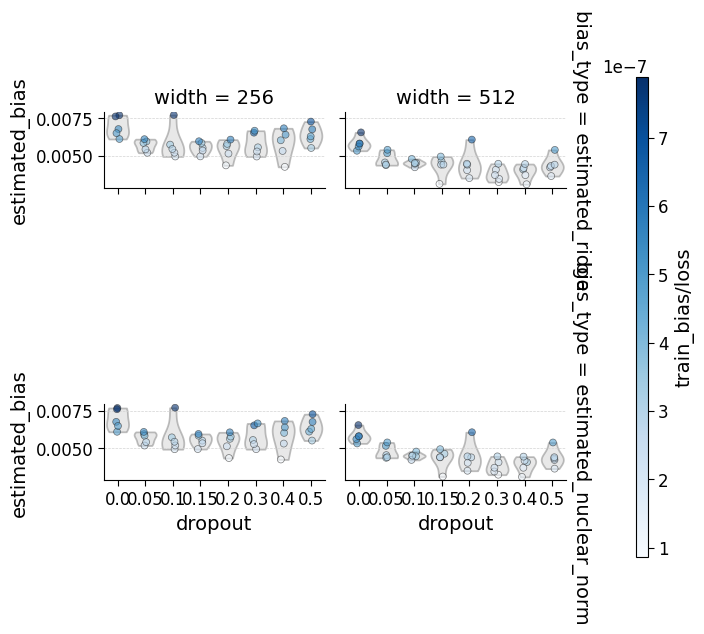

In [3]:
g = sns.FacetGrid(
    df_mixed_summary,
    col="width",
    row="bias_type",
    sharex=True,
    sharey=True,
    margin_titles=True,
)
g.map_dataframe(panelplot, x="dropout", y="estimated_bias", hue="train_bias/loss")

# add colorbar
cax = g.figure.add_axes([1.05, 0.1, 0.02, 0.8])
norm = mpl.colors.Normalize(
    vmin=df_mixed_summary["train_bias/loss"].min(),
    vmax=df_mixed_summary["train_bias/loss"].max(),
)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, cax=cax)
cbar.set_label("train_bias/loss")
plt.tight_layout()


## Measuring Collinearity of Gradients

In [ ]:
# Test with matrices of different ranks
import torch

n_samples = 100
n_features = 30


for n_features in [5, 10, 20, 30]:
    rank = n_features
    # Create matrix with specific condition number
    U, _ = torch.linalg.qr(torch.randn(n_samples, n_features))
    V, _ = torch.linalg.qr(torch.randn(n_features, n_features))
    
    # control the rank of the matrix and pad with zeros
    sigma = torch.linspace(10, 1, rank) 
    sigma = torch.cat([sigma, torch.zeros(n_features - rank)])
    # print(sigma)
    W = U @ torch.diag(sigma) @ V.T
    # print(W.shape)
    
    # Compute gradients
    grad_l2 = 2 * W
    
    # Nuclear norm gradient (requires autograd)
    W_param = W.detach().requires_grad_()
    nuclear = torch.linalg.matrix_norm(W_param, ord='nuc')
    nuclear.backward()
    grad_nuclear = W_param.grad

    # canonical nuclear norm grad (singular values change in the 
    # direction of the singular vector outer product)
    grad_nuclear_canonical = U @ V.T
    
    # Correlation
    cos_sim = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuclear.flatten().unsqueeze(0)
    )

    cos_sim_canonical = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuclear_canonical.flatten().unsqueeze(0)
    )

    print(torch.allclose(grad_nuclear, grad_nuclear_canonical, atol=1e-6))
    
    print(f"Rank: {rank:6.1f}, Bound 1/sqrt(r): {1/torch.sqrt(torch.tensor(rank)):.8f}, Correlation: {cos_sim.item():.8f}, Canonical: {cos_sim_canonical.item():.8f}")

True
Rank:    5.0, Bound 1/sqrt(r): 0.44721359, Correlation: 0.86557853, Canonical: 0.86557853
True
Rank:   10.0, Bound 1/sqrt(r): 0.31622776, Correlation: 0.88640523, Canonical: 0.88640529
True
Rank:   20.0, Bound 1/sqrt(r): 0.22360680, Correlation: 0.89563590, Canonical: 0.89563566
True
Rank:   30.0, Bound 1/sqrt(r): 0.18257418, Correlation: 0.89855933, Canonical: 0.89855927


In [35]:
## manipulate the spectrum of the weights to test the correlation of the grads
import torch

def canonical_nuclear_grad(W):
    U, S, Vt = torch.linalg.svd(W, full_matrices=False)
    return U @ Vt

def make_spectrum(rank, spike_ratio=100):
    """
    spike_ratio = sigma_max / sigma_min
    If spike_ratio = 1       → flat
    If spike_ratio = 1e6+    → very spiky
    """
    s = torch.logspace(0, -torch.log10(torch.tensor(float(spike_ratio))), rank)
    s = 10 * s / s.max()      # scale max to 10
    return s

n_samples = 300
n_features = 30

for r in [5, 10, 20, 30]:
    # r = n_features

    # RANDOM ORTHONORMAL FACTORS
    U, _ = torch.linalg.qr(torch.randn(n_samples, n_features))
    V, _ = torch.linalg.qr(torch.randn(n_features, n_features))

    # ***** CRITICAL PART: MAKE SPECTRUM VERY SPIKY *****
    # One large singular value, rest tiny
    # sigma = torch.zeros(n_features)
    sigma = make_spectrum(rank, 10)
    # pad with zeros to n_features
    sigma = torch.cat([sigma, torch.zeros(n_features - rank)])

    # Construct matrix
    W = U @ torch.diag(sigma) @ V.T

    # Gradients
    grad_l2 = 2 * W
    grad_nuc = canonical_nuclear_grad(W)

    # Cosine similarity
    cos = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuc.flatten().unsqueeze(0),
        dim=1
    ).item()

    print(f"Rank {r:2d} | 1/sqrt(r) bound = {1/ (r**0.5):.4f} | cosine = {cos:.8f}")

Rank  5 | 1/sqrt(r) bound = 0.4472 | cosine = 0.83546925
Rank 10 | 1/sqrt(r) bound = 0.3162 | cosine = 0.83546901
Rank 20 | 1/sqrt(r) bound = 0.2236 | cosine = 0.83546925
Rank 30 | 1/sqrt(r) bound = 0.1826 | cosine = 0.83546907


In [ ]:
# test how collinear the grads of the bias models for ridge and nuclear norm are
from core.bias import RidgeBias, NuclearNormBias, JointBias
from lightning.pytorch.callbacks import Callback
from lightning.pytorch import Trainer, LightningModule
from core.estimators import BiasWithMSE
from torch.utils.data import TensorDataset, DataLoader

ridge_bias = RidgeBias()
nuclear_norm_bias = NuclearNormBias()
joint_bias = JointBias([ridge_bias, nuclear_norm_bias])

# create a random weight matrix
weight_vector = torch.randn(10)

n_samples = 100
input = torch.randn(n_samples, 10)
# linear relationship between input and target
target = input @ weight_vector + torch.randn(n_samples)
dataset = TensorDataset(input, target)
dataloader = DataLoader(dataset, batch_size=10)
# compute the grads of the bias models

# train a linear layer to predict target from input
net = torch.nn.Sequential(torch.nn.Linear(10, 10), torch.nn.ReLU(), torch.nn.Linear(10, 1))

estimator = BiasWithMSE(
    predictive_model=net,
    bias_model=joint_bias,
    lr=0.1,
)


In [ ]:
class CheckPenaltyCorrelation(Callback):
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        X, y = batch
        
        # Get flattened params (same as in training_step)
        params = dict(pl_module.predictive_model.named_parameters())
        flattened_params = torch.cat([p.view(-1) for p in params.values()])
        flattened_params = flattened_params.detach().requires_grad_()
        
        # Recreate named_param_views
        offset = 0
        named_param_views = {}
        for name, param in params.items():
            numel = param.numel()
            view = flattened_params[offset : offset + numel].view_as(param)
            named_param_views[name] = view
            offset += numel
        
        # Compute individual penalties
        ridge_penalty = torch.sum(flattened_params.pow(2))
        nuclear_penalty = sum(
            torch.linalg.matrix_norm(
                p if p.ndim == 2 else p.reshape(p.shape[0], -1), ord="nuc"
            )
            for p in named_param_views.values() if p.ndim >= 2
        )
        
        # Get their gradients w.r.t. parameters
        grad_ridge = torch.autograd.grad(
            ridge_penalty, flattened_params, create_graph=False
        )[0]
        grad_nuclear = torch.autograd.grad(
            nuclear_penalty, flattened_params, create_graph=False
        )[0]
        
        # Compute cosine similarity
        cos_sim = torch.nn.functional.cosine_similarity(
            grad_ridge.unsqueeze(0), 
            grad_nuclear.unsqueeze(0)
        )
        
        pl_module.log("penalty_grad_correlation", cos_sim.item(), prog_bar=True)
class CheckBiasParams(Callback):
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        for bias_model in pl_module.bias_model.bias_models:
            for param in bias_model.parameters():
                pl_module.log(f"{bias_model.__class__.__name__}.{param.name}", param.data.item(), prog_bar=True)

trainer = Trainer(max_epochs=100, callbacks=[CheckPenaltyCorrelation(), CheckBiasParams()], accelerator="cpu")
trainer.fit(estimator, dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name             | Type       | Params | Mode 
--------------------------------------------------------
0 | predictive_model | Sequential | 121    | eval 
1 | bias_model       | JointBias  | 2      | train
--------------------------------------------------------
123       Trainable params
0         Non-trainable params
123       Total params
0.000     Total estimated model params size (MB)
4         Modules in train mode
4         Modules in eval mode
.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of traini

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [9]:
from typing import Dict, Tuple, List
import torch
import math

def sample_angle_torch(n: int, device: str = "cpu") -> float:
    """
    Sample one angle (in radians) between ∇||W||_F and ∇||W||_*,
    where W is Kaiming-uniform initialized in PyTorch.
    """
    # Create an (n x n) weight matrix
    W = torch.empty((n, n), device=device)
    torch.nn.init.kaiming_uniform_(W, a=math.sqrt(5))  # PyTorch default for Linear layers

    # SVD (full_matrices=False for speed)
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    # Gradients
    grad_fro = W / W.norm(p="fro")
    grad_nuc = U @ Vh

    # Cosine between two matrices = cosine between flattened vectors
    inner = torch.sum(grad_fro * grad_nuc)
    cos_theta = inner / (grad_fro.norm(p="fro") * grad_nuc.norm(p="fro"))

    # Numerical safety
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

    # Return angle in radians (convert to Python float)
    return float(torch.acos(cos_theta)), cos_theta


def estimate_angles_torch(
    dims: List[int], num_seeds: int = 20, device: str = "cpu"
) -> Dict[int, Tuple[float, float]]:
    """
    For each dimension n, run multiple seeds and compute:
    - mean angle (deg)
    - std angle (deg)
    """
    results: Dict[int, Tuple[float, float]] = {}

    for n in dims:
        angles_deg = []
        cos_thetas = []
        for _ in range(num_seeds):
            angle_rad, cos_theta = sample_angle_torch(n, device=device)
            angle_deg = float(torch.rad2deg(torch.tensor(angle_rad)))
            angles_deg.append(angle_deg)
            cos_thetas.append(cos_theta)

        angles_tensor = torch.tensor(angles_deg)
        results[n] = (float(angles_tensor.mean()), float(angles_tensor.std()), float(torch.tensor(cos_thetas).mean()))

    return results

dims = [10, 20, 50, 100, 200]
stats = estimate_angles_torch(dims, num_seeds=10)

for n, (mean_deg, std_deg, mean_cos) in stats.items():
    print(f"n={n:4d}: mean angle = {mean_deg:.2f}°, std = {std_deg:.2f}°, mean cos = {mean_cos:.2f}")

n=  10: mean angle = 33.02°, std = 2.47°, mean cos = 0.84
n=  20: mean angle = 31.53°, std = 1.56°, mean cos = 0.85
n=  50: mean angle = 31.96°, std = 0.48°, mean cos = 0.85
n= 100: mean angle = 31.94°, std = 0.15°, mean cos = 0.85
n= 200: mean angle = 31.92°, std = 0.10°, mean cos = 0.85


In [17]:
from core.bias import RidgeBias, NuclearNormBias
import torch
for i in range(10):
    linear = torch.nn.Linear(10, 10)

    # compare the grads of the l2 and nuclear bias models
    l2_bias = RidgeBias()
    nuclear_bias = NuclearNormBias()

    l2_penalty = l2_bias.forward(linear.weight) 
    nuclear_penalty = nuclear_bias.forward(linear.weight, named_params={"weight": linear.weight})
    l2_grad = torch.autograd.grad(l2_penalty, linear.weight)[0]
    nuclear_grad = torch.autograd.grad(nuclear_penalty, linear.weight)[0]

    # compute the cosine similarity between the grads
    cos = torch.nn.functional.cosine_similarity(
        l2_grad.flatten().unsqueeze(0),
        nuclear_grad.flatten().unsqueeze(0)
    )
    print("cosine similarity = ", cos.item(), "ratio l2/nuclear = ", l2_penalty.item() / nuclear_penalty.item())

cosine similarity =  0.8132991194725037 ratio l2/nuclear =  0.7645479981435427
cosine similarity =  0.816142201423645 ratio l2/nuclear =  0.6602336427503479
cosine similarity =  0.8714557886123657 ratio l2/nuclear =  0.6796871500442425
cosine similarity =  0.827344536781311 ratio l2/nuclear =  0.836685082688362
cosine similarity =  0.8494673371315002 ratio l2/nuclear =  0.7910871682878066
cosine similarity =  0.8370914459228516 ratio l2/nuclear =  0.6136163229221588
cosine similarity =  0.8455343246459961 ratio l2/nuclear =  0.665622796280618
cosine similarity =  0.8145498037338257 ratio l2/nuclear =  0.7967804155544213
cosine similarity =  0.8577067852020264 ratio l2/nuclear =  0.7339755011651533
cosine similarity =  0.8753446936607361 ratio l2/nuclear =  0.5928327904510388


In [27]:
from core.bias import RidgeBias, LassoBias
import torch
for i in range(10):

    # toy example, train a linear model with l2 and lasso penalty
    simple_net = torch.nn.Sequential(
        torch.nn.Linear(10, 10),
        torch.nn.ReLU(),
        torch.nn.Linear(10, 1),
    )

    X = torch.randn(100, 10)
    y = torch.randn(100, 1)

    # compare the grads of the l2 and nuclear bias models
    l2_bias = RidgeBias()
    lasso_bias = LassoBias()

    # set the bias parameters
    l2_bias.beta.data = torch.tensor(0.001)
    lasso_bias.alpha.data = torch.tensor(0.001)

    l2_bias.eval()
    lasso_bias.eval()

    # train the model
    optimizer = torch.optim.Adam(simple_net.parameters(), lr=0.01)
    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = simple_net(X)
        loss = torch.nn.functional.mse_loss(y_pred, y)
        l2_penalty = l2_bias.forward(linear.weight) 
        lasso_penalty = lasso_bias.forward(linear.weight, named_params={"weight": linear.weight})
        loss += l2_penalty
        loss += lasso_penalty
        loss.backward()
        optimizer.step()

    
    l2_bias = RidgeBias()
    lasso_bias = LassoBias()

    flattened_params = (
            torch.cat([p.view(-1) for p in simple_net.parameters()]).detach().requires_grad_()
        )   
    l2_penalty = l2_bias.forward(flattened_params) 
    lasso_penalty = lasso_bias.forward(flattened_params)
    l2_grad = torch.autograd.grad(l2_penalty, flattened_params)[0]
    lasso_grad = torch.autograd.grad(lasso_penalty, flattened_params)[0]

    # compute the cosine similarity between the grads   
    cos = torch.nn.functional.cosine_similarity(
        l2_grad.flatten().unsqueeze(0),
        lasso_grad.flatten().unsqueeze(0)
    )
    print("cosine similarity = ", cos.item())
    print("ratio l2/lasso = ", l2_penalty.item() / lasso_penalty.item())


cosine similarity =  0.8261865377426147
ratio l2/lasso =  0.5083815139580207
cosine similarity =  0.8317606449127197
ratio l2/lasso =  0.4547864918345418
cosine similarity =  0.8219996690750122
ratio l2/lasso =  0.4613916937247041
cosine similarity =  0.8344362378120422
ratio l2/lasso =  0.702464433953559
cosine similarity =  0.8176573514938354
ratio l2/lasso =  0.5386742382634514


cosine similarity =  0.8327957391738892
ratio l2/lasso =  0.5398148370252315
cosine similarity =  0.8291133642196655
ratio l2/lasso =  0.6006707129034508
cosine similarity =  0.8349703550338745
ratio l2/lasso =  0.49608618659070197
cosine similarity =  0.8139193058013916
ratio l2/lasso =  0.44045257845811664
cosine similarity =  0.8207443952560425
ratio l2/lasso =  0.5991690344430782


In [8]:
from core.bias import RidgeBias, OrthogonalBias
import torch
from typing import Dict

def vector_to_parameter_views(vector: torch.Tensor, model: torch.nn.Module) -> Dict[str, torch.Tensor]:
    """
    Creates a dictionary of views into 'vector' that match the structure of 'model.named_parameters()'.
    The returned views are part of the same computational graph as 'vector'.
    """
    pointer = 0
    views = []
    for param in model.parameters():
        numel = param.numel()
        views.append(vector[pointer : pointer + numel].view_as(param))
        pointer += numel
    return views

for i in range(10):
    # toy example, train a linear model with l2 and lasso penalty
    simple_net = torch.nn.Sequential(
        torch.nn.Linear(10, 10),
        torch.nn.ReLU(),
        torch.nn.Linear(10, 1),
    )

    X = torch.randn(100, 10)
    y = torch.randn(100, 1)

    # compare the grads of the l2 and nuclear bias models
    l2_bias = RidgeBias()
    orthogonal_bias = OrthogonalBias()

    # set the bias parameters
    l2_bias.beta.data = torch.tensor(0.001)
    orthogonal_bias.beta.data = torch.tensor(0.001)

    l2_bias.eval()
    orthogonal_bias.eval()

    # train the model
    optimizer = torch.optim.Adam(simple_net.parameters(), lr=0.01)
    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = simple_net(X)
        loss = torch.nn.functional.mse_loss(y_pred, y)
        flattened_params = torch.nn.utils.parameters_to_vector(simple_net.parameters())
        params = vector_to_parameter_views(flattened_params, simple_net)
        l2_penalty = l2_bias.forward(flattened_params) 
        orthogonal_penalty = orthogonal_bias.forward(flattened_params, structured_params=params)
        loss += l2_penalty
        loss += orthogonal_penalty
        loss.backward()
        optimizer.step()

    
    l2_bias = RidgeBias()
    orthogonal_bias = OrthogonalBias()

    flattened_params = torch.nn.utils.parameters_to_vector(simple_net.parameters()).detach().requires_grad_()
    params = vector_to_parameter_views(flattened_params, simple_net)

    l2_penalty = l2_bias.forward(flattened_params) 
    orthogonal_penalty = orthogonal_bias.forward(flattened_params, structured_params=params)
    l2_grad = torch.autograd.grad(l2_penalty, flattened_params)[0]
    orthogonal_grad = torch.autograd.grad(orthogonal_penalty, flattened_params)[0]

    # compute the cosine similarity between the grads
    cos = torch.nn.functional.cosine_similarity(
        l2_grad.flatten().unsqueeze(0),
        orthogonal_grad.flatten().unsqueeze(0)
    )
    print("cosine similarity = ", cos.item(), "ratio l2/orthogonal = ", l2_penalty.item() / orthogonal_penalty.item())

cosine similarity =  -0.9989519715309143 ratio l2/orthogonal =  2.3759113831812946
cosine similarity =  -0.99910569190979 ratio l2/orthogonal =  2.2391519174562173
cosine similarity =  -0.999068021774292 ratio l2/orthogonal =  1.9431150064593254


cosine similarity =  -0.9984003901481628 ratio l2/orthogonal =  1.737556620020442
cosine similarity =  -0.9988211393356323 ratio l2/orthogonal =  2.5185937455047616
cosine similarity =  -0.9994031190872192 ratio l2/orthogonal =  1.7667736464643367
cosine similarity =  -0.9986937046051025 ratio l2/orthogonal =  2.594098004593568
cosine similarity =  -0.9986169338226318 ratio l2/orthogonal =  2.5210369042117025
cosine similarity =  -0.9982656240463257 ratio l2/orthogonal =  2.222442748600299
cosine similarity =  -0.9989874958992004 ratio l2/orthogonal =  2.5745386661318523


## Verify Scale-Invariant Biases are Orthogonal to L2

The following biases are scale-invariant (f(αW) = f(W)), so their gradients should be orthogonal to W.
Since L2 gradient is 2W, we expect cosine similarity ≈ 0 between these biases and RidgeBias.


In [4]:
from core.bias import (
    RidgeBias,
    StableRankBias,
    SpectralEntropyBias,
    WeightCoherenceBias,
    RowNormVarianceBias,
    SpectralGapBias,
    NuclearNormBias,
)
import torch
import pandas as pd

def compute_gradient_cosine_similarity(bias_a, bias_b, weight_matrix):
    """Compute cosine similarity between gradients of two bias functions."""
    w = weight_matrix.detach().clone().requires_grad_(True)
    flattened = w.flatten()
    structured = [w]
    
    # Compute gradient of bias_a
    penalty_a = bias_a.forward(flattened, structured)
    grad_a = torch.autograd.grad(penalty_a, w, create_graph=False)[0]
    
    # Reset for bias_b
    w = weight_matrix.detach().clone().requires_grad_(True)
    flattened = w.flatten()
    structured = [w]
    
    penalty_b = bias_b.forward(flattened, structured)
    grad_b = torch.autograd.grad(penalty_b, w, create_graph=False)[0]
    
    # Cosine similarity
    cos_sim = torch.nn.functional.cosine_similarity(
        grad_a.flatten().unsqueeze(0),
        grad_b.flatten().unsqueeze(0)
    )
    return cos_sim.item()

# Test with random matrices of various sizes
bias_classes = [
    ("RidgeBias", RidgeBias),
    ("NuclearNormBias", NuclearNormBias),
    ("StableRankBias", StableRankBias),
    ("SpectralEntropyBias", SpectralEntropyBias),
    ("WeightCoherenceBias", WeightCoherenceBias),
    ("RowNormVarianceBias", RowNormVarianceBias),
    ("SpectralGapBias", SpectralGapBias),
]

results = []
for n_features in [10, 50, 100]:
    for seed in range(5):
        torch.manual_seed(seed)
        W = torch.randn(n_features, n_features)
        # Kaiming initialization
        torch.nn.init.kaiming_uniform_(W)
        
        ridge_bias = RidgeBias(enforce_positive=False)
        ridge_bias.beta.data = torch.tensor(1.0)
        
        for name, BiasClass in bias_classes[1:]:  # Skip RidgeBias itself
            other_bias = BiasClass(enforce_positive=False)
            other_bias.beta.data = torch.tensor(1.0)
            
            cos_sim = compute_gradient_cosine_similarity(ridge_bias, other_bias, W)
            results.append({
                "n_features": n_features,
                "seed": seed,
                "bias": name,
                "cosine_with_ridge": cos_sim,
            })

df_results = pd.DataFrame(results)

# Summary statistics
summary = df_results.groupby("bias")["cosine_with_ridge"].agg(["mean", "std"]).round(4)
summary["abs_mean"] = df_results.groupby("bias")["cosine_with_ridge"].apply(lambda x: x.abs().mean()).round(4)
print("Cosine Similarity with Ridge (L2) Gradient:")
print("=" * 60)
print(summary.sort_values("abs_mean"))
print("\n(Scale-invariant biases should have |cosine| ≈ 0)")


Cosine Similarity with Ridge (L2) Gradient:
                      mean     std  abs_mean
bias                                        
RowNormVarianceBias -0.000  0.0000     0.000
SpectralEntropyBias  0.000  0.0000     0.000
SpectralGapBias     -0.000  0.0000     0.000
StableRankBias      -0.000  0.0000     0.000
WeightCoherenceBias  0.000  0.0000     0.000
NuclearNormBias      0.846  0.0069     0.846

(Scale-invariant biases should have |cosine| ≈ 0)


Pairwise Cosine Similarity Between Scale-Invariant Biases:
                 StableRank  SpectralEntropy  WeightCoherence  \
StableRank            1.000            0.317           -0.486   
SpectralEntropy       0.317            1.000           -0.903   
WeightCoherence      -0.486           -0.903            1.000   
RowNormVariance      -0.078           -0.120            0.139   
SpectralGap          -0.709           -0.036            0.087   

                 RowNormVariance  SpectralGap  
StableRank                -0.078       -0.709  
SpectralEntropy           -0.120       -0.036  
WeightCoherence            0.139        0.087  
RowNormVariance            1.000        0.010  
SpectralGap                0.010        1.000  

(Diagonal = 1.0, off-diagonal should be close to 0 for identifiability)


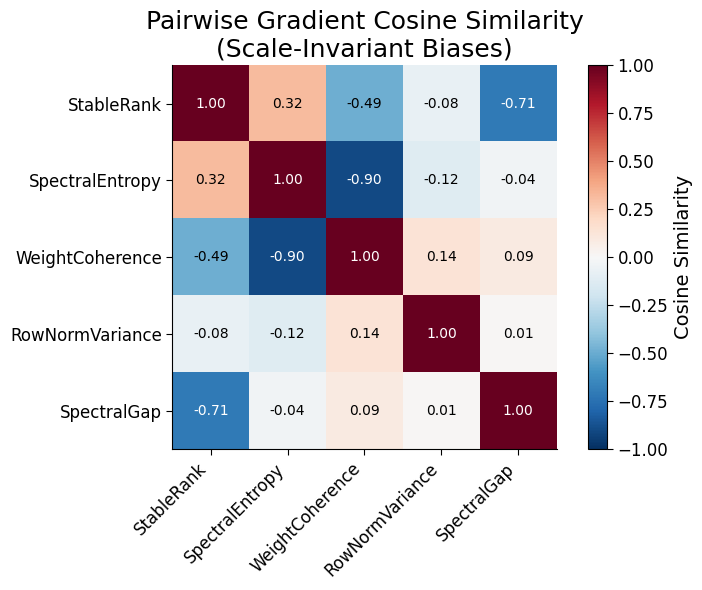

In [5]:
# Pairwise cosine similarity between all scale-invariant biases
import numpy as np
import matplotlib.pyplot as plt

scale_invariant_biases = [
    ("StableRank", StableRankBias),
    ("SpectralEntropy", SpectralEntropyBias),
    ("WeightCoherence", WeightCoherenceBias),
    ("RowNormVariance", RowNormVarianceBias),
    ("SpectralGap", SpectralGapBias),
]

# Compute average pairwise cosine similarity across multiple random matrices
n_samples = 10
n_features = 50

pairwise_cos = np.zeros((len(scale_invariant_biases), len(scale_invariant_biases)))

for seed in range(n_samples):
    torch.manual_seed(seed)
    W = torch.randn(n_features, n_features)
    torch.nn.init.kaiming_uniform_(W)
    
    for i, (name_i, BiasClass_i) in enumerate(scale_invariant_biases):
        for j, (name_j, BiasClass_j) in enumerate(scale_invariant_biases):
            bias_i = BiasClass_i(enforce_positive=False)
            bias_i.beta.data = torch.tensor(1.0)
            bias_j = BiasClass_j(enforce_positive=False)
            bias_j.beta.data = torch.tensor(1.0)
            
            cos_sim = compute_gradient_cosine_similarity(bias_i, bias_j, W)
            pairwise_cos[i, j] += cos_sim / n_samples

# Create DataFrame for display
names = [name for name, _ in scale_invariant_biases]
df_pairwise = pd.DataFrame(pairwise_cos, index=names, columns=names).round(3)

print("Pairwise Cosine Similarity Between Scale-Invariant Biases:")
print("=" * 70)
print(df_pairwise)
print("\n(Diagonal = 1.0, off-diagonal should be close to 0 for identifiability)")

# Visualize as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pairwise_cos, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{pairwise_cos[i, j]:.2f}", ha="center", va="center", 
                color="white" if abs(pairwise_cos[i, j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.title("Pairwise Gradient Cosine Similarity\n(Scale-Invariant Biases)")
plt.tight_layout()
plt.show()


## Gradient-Based Biases

Two categories:
1. **True gradient measures** - require gradient vector (GradientEntropy, GradientSparsity, WeightGradientAlignment)
2. **Gradient-flow proxies** - weight-based but capture gradient dynamics (LayerNormProduct, LayerNormBalance, EffectiveDepth)


In [6]:
from core.bias import (
    LayerNormProductBias,
    LayerNormBalanceBias,
    EffectiveDepthBias,
    GradientEntropyBias,
    GradientSparsityBias,
    WeightGradientAlignmentBias,
)

# Test gradient-flow proxies (weight-based) for orthogonality to L2
gradient_flow_biases = [
    ("LayerNormProduct", LayerNormProductBias),
    ("LayerNormBalance", LayerNormBalanceBias),
    ("EffectiveDepth", EffectiveDepthBias),
]

# Test with multi-layer networks (list of weight matrices)
results_gf = []
for n_layers in [3, 5, 8]:
    for seed in range(5):
        torch.manual_seed(seed)
        # Simulate a multi-layer network
        width = 50
        structured_params = [torch.randn(width, width) for _ in range(n_layers)]
        for w in structured_params:
            torch.nn.init.kaiming_uniform_(w)
        flattened = torch.cat([w.flatten() for w in structured_params])
        
        ridge_bias = RidgeBias(enforce_positive=False)
        ridge_bias.beta.data = torch.tensor(1.0)
        
        for name, BiasClass in gradient_flow_biases:
            other_bias = BiasClass(enforce_positive=False)
            other_bias.beta.data = torch.tensor(1.0)
            
            # Compute gradients manually for multi-layer case
            w_all = flattened.detach().clone().requires_grad_(True)
            structured_views = []
            offset = 0
            for orig_w in structured_params:
                numel = orig_w.numel()
                structured_views.append(w_all[offset:offset+numel].reshape(orig_w.shape))
                offset += numel
            
            # Ridge gradient
            penalty_ridge = ridge_bias.forward(w_all, structured_views)
            grad_ridge = torch.autograd.grad(penalty_ridge, w_all)[0]
            
            # Other bias gradient
            w_all2 = flattened.detach().clone().requires_grad_(True)
            structured_views2 = []
            offset = 0
            for orig_w in structured_params:
                numel = orig_w.numel()
                structured_views2.append(w_all2[offset:offset+numel].reshape(orig_w.shape))
                offset += numel
            penalty_other = other_bias.forward(w_all2, structured_views2)
            grad_other = torch.autograd.grad(penalty_other, w_all2)[0]
            
            cos_sim = torch.nn.functional.cosine_similarity(
                grad_ridge.unsqueeze(0), grad_other.unsqueeze(0)
            ).item()
            
            results_gf.append({
                "n_layers": n_layers,
                "seed": seed,
                "bias": name,
                "cosine_with_ridge": cos_sim,
            })

df_gf = pd.DataFrame(results_gf)
summary_gf = df_gf.groupby("bias")["cosine_with_ridge"].agg(["mean", "std"]).round(4)
summary_gf["abs_mean"] = df_gf.groupby("bias")["cosine_with_ridge"].apply(lambda x: x.abs().mean()).round(4)
print("Gradient-Flow Proxy Biases: Cosine Similarity with Ridge (L2)")
print("=" * 65)
print(summary_gf.sort_values("abs_mean"))
print("\n(LayerNormBalance and EffectiveDepth should be near 0 - scale invariant)")


Gradient-Flow Proxy Biases: Cosine Similarity with Ridge (L2)
                  mean    std  abs_mean
bias                                   
EffectiveDepth    0.00  0.000      0.00
LayerNormBalance -0.00  0.000      0.00
LayerNormProduct  0.27  0.004      0.27

(LayerNormBalance and EffectiveDepth should be near 0 - scale invariant)


Full Pairwise Cosine Similarity (including Ridge and Gradient-Flow Proxies):
                  Ridge  StableRank  SpectralEntropy  WeightCoherence  \
Ridge               1.0       -0.00             0.00            -0.00   
StableRank         -0.0        1.00             0.30            -0.46   
SpectralEntropy     0.0        0.30             1.00            -0.90   
WeightCoherence    -0.0       -0.46            -0.90             1.00   
RowNormVariance     0.0       -0.05            -0.11             0.13   
SpectralGap        -0.0       -0.72            -0.02             0.06   
LayerNormBalance   -0.0        0.07            -0.01             0.03   
EffectiveDepth      0.0        0.01             0.03            -0.01   

                  RowNormVariance  SpectralGap  LayerNormBalance  \
Ridge                        0.00        -0.00             -0.00   
StableRank                  -0.05        -0.72              0.07   
SpectralEntropy             -0.11        -0.02             -0

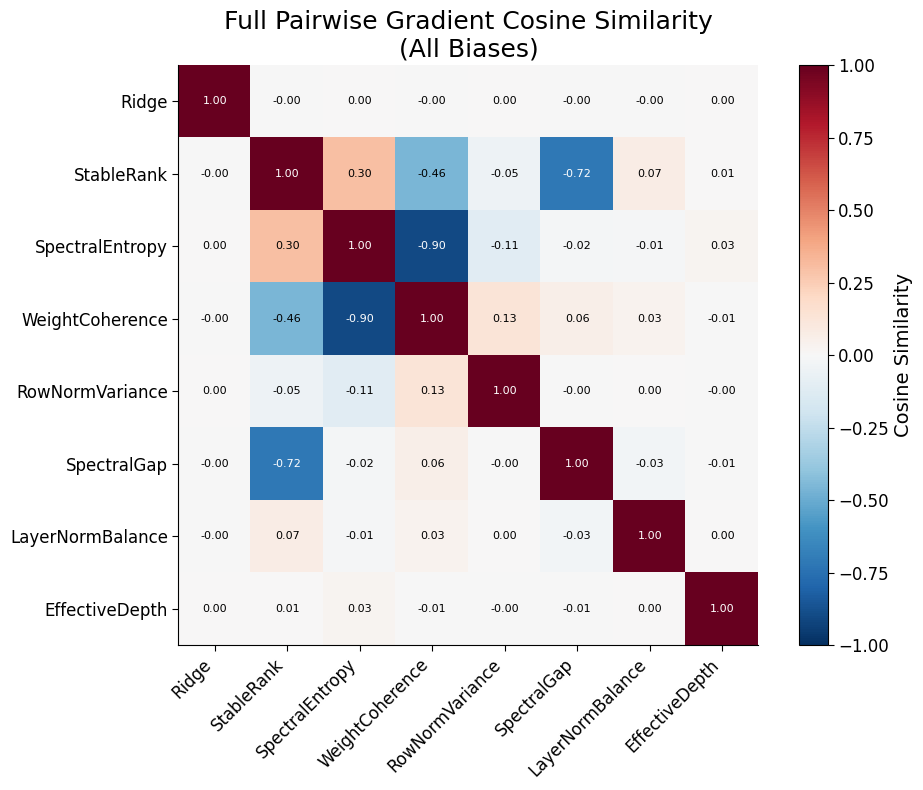

In [7]:
# Full pairwise comparison including gradient-flow proxies
all_biases = [
    ("Ridge", RidgeBias),
    ("StableRank", StableRankBias),
    ("SpectralEntropy", SpectralEntropyBias),
    ("WeightCoherence", WeightCoherenceBias),
    ("RowNormVariance", RowNormVarianceBias),
    ("SpectralGap", SpectralGapBias),
    ("LayerNormBalance", LayerNormBalanceBias),
    ("EffectiveDepth", EffectiveDepthBias),
]

n_samples = 10
n_layers = 5
width = 50

pairwise_all = np.zeros((len(all_biases), len(all_biases)))

for seed in range(n_samples):
    torch.manual_seed(seed)
    structured_params = [torch.randn(width, width) for _ in range(n_layers)]
    for w in structured_params:
        torch.nn.init.kaiming_uniform_(w)
    
    for i, (name_i, BiasClass_i) in enumerate(all_biases):
        for j, (name_j, BiasClass_j) in enumerate(all_biases):
            bias_i = BiasClass_i(enforce_positive=False)
            bias_i.beta.data = torch.tensor(1.0)
            bias_j = BiasClass_j(enforce_positive=False)
            bias_j.beta.data = torch.tensor(1.0)
            
            # Compute gradients
            flattened = torch.cat([w.flatten() for w in structured_params])
            w_all = flattened.detach().clone().requires_grad_(True)
            structured_views = []
            offset = 0
            for orig_w in structured_params:
                numel = orig_w.numel()
                structured_views.append(w_all[offset:offset+numel].reshape(orig_w.shape))
                offset += numel
            penalty_i = bias_i.forward(w_all, structured_views)
            grad_i = torch.autograd.grad(penalty_i, w_all)[0]
            
            w_all2 = flattened.detach().clone().requires_grad_(True)
            structured_views2 = []
            offset = 0
            for orig_w in structured_params:
                numel = orig_w.numel()
                structured_views2.append(w_all2[offset:offset+numel].reshape(orig_w.shape))
                offset += numel
            penalty_j = bias_j.forward(w_all2, structured_views2)
            grad_j = torch.autograd.grad(penalty_j, w_all2)[0]
            
            cos_sim = torch.nn.functional.cosine_similarity(
                grad_i.unsqueeze(0), grad_j.unsqueeze(0)
            ).item()
            pairwise_all[i, j] += cos_sim / n_samples

names_all = [name for name, _ in all_biases]
df_all = pd.DataFrame(pairwise_all, index=names_all, columns=names_all).round(2)
print("Full Pairwise Cosine Similarity (including Ridge and Gradient-Flow Proxies):")
print("=" * 80)
print(df_all)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pairwise_all, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(names_all)))
ax.set_yticks(range(len(names_all)))
ax.set_xticklabels(names_all, rotation=45, ha="right")
ax.set_yticklabels(names_all)
for i in range(len(names_all)):
    for j in range(len(names_all)):
        ax.text(j, i, f"{pairwise_all[i, j]:.2f}", ha="center", va="center", 
                color="white" if abs(pairwise_all[i, j]) > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.title("Full Pairwise Gradient Cosine Similarity\n(All Biases)")
plt.tight_layout()
plt.show()


In [12]:
# Test TRUE gradient measures (require actual loss gradients)
# These measure properties of the gradient itself, not just the weights
#
# NOTE: GradientEntropy and GradientSparsity only depend on grad_vector, NOT on weights!
# So we can't compute their gradient w.r.t. weights in the traditional sense.
# Only WeightGradientAlignment uses both weights and gradients.

true_gradient_biases = [
    ("GradientEntropy", GradientEntropyBias),
    ("GradientSparsity", GradientSparsityBias),
    ("WeightGradientAlignment", WeightGradientAlignmentBias),
]

# Which biases actually depend on weights?
weight_dependent_biases = [("WeightGradientAlignment", WeightGradientAlignmentBias)]
gradient_only_biases = [("GradientEntropy", GradientEntropyBias), ("GradientSparsity", GradientSparsityBias)]

def compute_loss_gradient(net, X, y):
    """Compute gradient of loss w.r.t. all parameters."""
    net.zero_grad()
    logits = net(X)
    loss = torch.nn.functional.cross_entropy(logits, y)
    loss.backward()
    grad_vector = torch.cat([p.grad.flatten() for p in net.parameters() if p.grad is not None])
    return grad_vector

# Test WeightGradientAlignment (the only one that depends on weights)
print("=" * 70)
print("WeightGradientAlignment: Cosine Similarity with Ridge (L2)")
print("=" * 70)

results_wga = []
for seed in range(10):
    torch.manual_seed(seed)
    
    net = torch.nn.Sequential(
        torch.nn.Linear(50, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 10),
    )
    
    X = torch.randn(32, 50)
    y = torch.randint(0, 10, (32,))
    grad_vector = compute_loss_gradient(net, X, y).detach()
    
    flattened_params = torch.cat([p.flatten() for p in net.parameters()]).detach().requires_grad_(True)
    structured_views = []
    offset = 0
    for p in net.parameters():
        numel = p.numel()
        structured_views.append(flattened_params[offset:offset+numel].reshape(p.shape))
        offset += numel
    
    # Ridge gradient
    ridge_bias = RidgeBias(enforce_positive=False)
    ridge_bias.beta.data = torch.tensor(1.0)
    penalty_ridge = ridge_bias.forward(flattened_params, structured_views)
    grad_ridge = torch.autograd.grad(penalty_ridge, flattened_params)[0]
    
    # WeightGradientAlignment gradient
    flattened_params2 = torch.cat([p.flatten() for p in net.parameters()]).detach().requires_grad_(True)
    structured_views2 = []
    offset = 0
    for p in net.parameters():
        numel = p.numel()
        structured_views2.append(flattened_params2[offset:offset+numel].reshape(p.shape))
        offset += numel
    
    wga_bias = WeightGradientAlignmentBias(enforce_positive=False)
    wga_bias.beta.data = torch.tensor(1.0)
    penalty_wga = wga_bias.forward(flattened_params2, structured_views2, grad_vector=grad_vector)
    grad_wga = torch.autograd.grad(penalty_wga, flattened_params2)[0]
    
    cos_sim = torch.nn.functional.cosine_similarity(
        grad_ridge.unsqueeze(0), grad_wga.unsqueeze(0)
    ).item()
    results_wga.append({"seed": seed, "cosine_with_ridge": cos_sim})

df_wga = pd.DataFrame(results_wga)
print(f"WeightGradientAlignment vs Ridge: mean={df_wga['cosine_with_ridge'].mean():.4f}, std={df_wga['cosine_with_ridge'].std():.4f}")

# For GradientEntropy and GradientSparsity, we compare the LOSS GRADIENT direction
# to the gradient these biases would induce if used as regularizers
print("\n" + "=" * 70)
print("GradientEntropy & GradientSparsity: Properties of the Loss Gradient")
print("=" * 70)
print("(These don't depend on weights - they measure gradient structure)")

results_grad_props = []
for seed in range(10):
    torch.manual_seed(seed)
    
    net = torch.nn.Sequential(
        torch.nn.Linear(50, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 10),
    )
    
    X = torch.randn(32, 50)
    y = torch.randint(0, 10, (32,))
    grad_vector = compute_loss_gradient(net, X, y).detach()
    flattened_params = torch.cat([p.flatten() for p in net.parameters()]).detach()
    
    # Compute values of gradient-only biases
    ge_bias = GradientEntropyBias(enforce_positive=False)
    ge_bias.beta.data = torch.tensor(1.0)
    entropy_val = ge_bias.forward(flattened_params, [], grad_vector=grad_vector).item()
    
    gs_bias = GradientSparsityBias(enforce_positive=False)
    gs_bias.beta.data = torch.tensor(1.0)
    sparsity_val = gs_bias.forward(flattened_params, [], grad_vector=grad_vector).item()
    
    # Also compute normalized metrics
    n_params = grad_vector.numel()
    max_entropy = np.log(n_params)  # uniform distribution
    max_sparsity = np.sqrt(n_params)  # uniform distribution (L1/L2 = sqrt(n))
    
    results_grad_props.append({
        "seed": seed,
        "gradient_entropy": entropy_val,
        "normalized_entropy": entropy_val / max_entropy,
        "gradient_sparsity": sparsity_val,
        "normalized_sparsity": sparsity_val / max_sparsity,
    })

df_grad_props = pd.DataFrame(results_grad_props)
print(f"\nGradient Entropy: mean={df_grad_props['gradient_entropy'].mean():.2f} (normalized: {df_grad_props['normalized_entropy'].mean():.3f})")
print(f"Gradient Sparsity (L1/L2): mean={df_grad_props['gradient_sparsity'].mean():.2f} (normalized: {df_grad_props['normalized_sparsity'].mean():.3f})")
print(f"\n(Normalized values: 1.0 = uniform/dense, 0.0 = concentrated/sparse)")


WeightGradientAlignment: Cosine Similarity with Ridge (L2)
WeightGradientAlignment vs Ridge: mean=0.0000, std=0.0000

GradientEntropy & GradientSparsity: Properties of the Loss Gradient
(These don't depend on weights - they measure gradient structure)

Gradient Entropy: mean=7.80 (normalized: 0.805)
Gradient Sparsity (L1/L2): mean=80.77 (normalized: 0.634)

(Normalized values: 1.0 = uniform/dense, 0.0 = concentrated/sparse)


Correlation between GradientEntropy and GradientSparsity VALUES:
Pearson correlation: 0.9850
(High correlation expected: both measure how 'spread out' the gradient is)


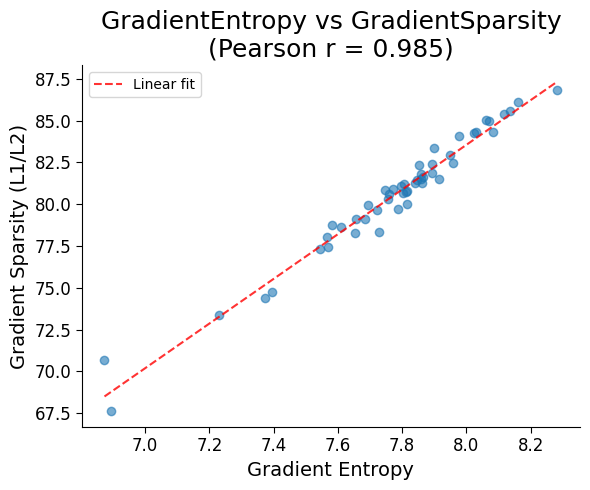

In [13]:
# Correlation between GradientEntropy and GradientSparsity values
# (Since these don't depend on weights, we compare their VALUES not their weight-gradients)

print("Correlation between GradientEntropy and GradientSparsity VALUES:")
print("=" * 65)

# Collect values across many networks
all_entropy = []
all_sparsity = []

for seed in range(50):
    torch.manual_seed(seed)
    
    net = torch.nn.Sequential(
        torch.nn.Linear(50, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 10),
    )
    
    X = torch.randn(32, 50)
    y = torch.randint(0, 10, (32,))
    grad_vector = compute_loss_gradient(net, X, y).detach()
    flattened = torch.cat([p.flatten() for p in net.parameters()]).detach()
    
    ge_bias = GradientEntropyBias(enforce_positive=False)
    ge_bias.beta.data = torch.tensor(1.0)
    entropy_val = ge_bias.forward(flattened, [], grad_vector=grad_vector).item()
    
    gs_bias = GradientSparsityBias(enforce_positive=False)
    gs_bias.beta.data = torch.tensor(1.0)
    sparsity_val = gs_bias.forward(flattened, [], grad_vector=grad_vector).item()
    
    all_entropy.append(entropy_val)
    all_sparsity.append(sparsity_val)

# Compute correlation
entropy_arr = np.array(all_entropy)
sparsity_arr = np.array(all_sparsity)
correlation = np.corrcoef(entropy_arr, sparsity_arr)[0, 1]

print(f"Pearson correlation: {correlation:.4f}")
print("(High correlation expected: both measure how 'spread out' the gradient is)")

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(entropy_arr, sparsity_arr, alpha=0.6)
ax.set_xlabel("Gradient Entropy")
ax.set_ylabel("Gradient Sparsity (L1/L2)")
ax.set_title(f"GradientEntropy vs GradientSparsity\n(Pearson r = {correlation:.3f})")

# Add trend line
z = np.polyfit(entropy_arr, sparsity_arr, 1)
p = np.poly1d(z)
x_line = np.linspace(entropy_arr.min(), entropy_arr.max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, label="Linear fit")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
# Direct comparison: Loss gradient vs Regularizer gradients
# All of these live in the same parameter space!
#
# ∇L (loss gradient) vs ∇R (regularizer gradient)
# Question: How aligned is the loss gradient with various regularizers?

print("=" * 70)
print("Cosine Similarity: Loss Gradient (∇L) vs Regularizer Gradients (∇R)")
print("=" * 70)
print("(This asks: is the loss already pushing in the direction of the regularizer?)")

results_loss_vs_reg = []

for seed in range(20):
    torch.manual_seed(seed)
    
    net = torch.nn.Sequential(
        torch.nn.Linear(50, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 10),
    )
    
    X = torch.randn(32, 50)
    y = torch.randint(0, 10, (32,))
    
    # Loss gradient (in parameter space)
    loss_grad = compute_loss_gradient(net, X, y).detach()
    
    # Flatten weights
    flattened_params = torch.cat([p.flatten() for p in net.parameters()]).detach().requires_grad_(True)
    structured_views = []
    offset = 0
    for p in net.parameters():
        numel = p.numel()
        structured_views.append(flattened_params[offset:offset+numel].reshape(p.shape))
        offset += numel
    
    # Regularizers to compare
    regularizers = [
        ("Ridge (L2)", RidgeBias),
        ("StableRank", StableRankBias),
        ("SpectralEntropy", SpectralEntropyBias),
        ("RowNormVariance", RowNormVarianceBias),
        ("LayerNormBalance", LayerNormBalanceBias),
        ("EffectiveDepth", EffectiveDepthBias),
    ]
    
    for name, BiasClass in regularizers:
        bias = BiasClass(enforce_positive=False)
        bias.beta.data = torch.tensor(1.0)
        
        # Fresh computation graph
        fp = torch.cat([p.flatten() for p in net.parameters()]).detach().requires_grad_(True)
        sv = []
        offset = 0
        for p in net.parameters():
            numel = p.numel()
            sv.append(fp[offset:offset+numel].reshape(p.shape))
            offset += numel
        
        penalty = bias.forward(fp, sv)
        reg_grad = torch.autograd.grad(penalty, fp)[0]
        
        # Cosine similarity between loss gradient and regularizer gradient
        cos_sim = torch.nn.functional.cosine_similarity(
            loss_grad.unsqueeze(0), reg_grad.unsqueeze(0)
        ).item()
        
        results_loss_vs_reg.append({
            "seed": seed,
            "regularizer": name,
            "cos_sim_with_loss_grad": cos_sim,
        })

df_loss_vs_reg = pd.DataFrame(results_loss_vs_reg)
summary_lvr = df_loss_vs_reg.groupby("regularizer")["cos_sim_with_loss_grad"].agg(["mean", "std"]).round(4)
print("\nCosine Similarity: ∇L vs ∇R(egularizer)")
print(summary_lvr.sort_values("mean", ascending=False))

print("\nInterpretation:")
print("- Positive: Loss naturally pushes in same direction as regularizer")
print("- Negative: Loss pushes against regularizer (tension)")
print("- Near zero: Loss and regularizer are orthogonal (independent effects)")


Cosine Similarity: Loss Gradient (∇L) vs Regularizer Gradients (∇R)
(This asks: is the loss already pushing in the direction of the regularizer?)

Cosine Similarity: ∇L vs ∇R(egularizer)
                    mean     std
regularizer                     
Ridge (L2)        0.0099  0.0158
EffectiveDepth   -0.0018  0.0109
StableRank       -0.0022  0.0057
LayerNormBalance -0.0031  0.0139
SpectralEntropy  -0.0031  0.0154
RowNormVariance  -0.0075  0.0150

Interpretation:
- Positive: Loss naturally pushes in same direction as regularizer
- Negative: Loss pushes against regularizer (tension)
- Near zero: Loss and regularizer are orthogonal (independent effects)


In [17]:
# Treating gradient-based measures AS REGULARIZERS
# This requires second-order gradients (Hessian-vector products)
#
# If we add GradientEntropy(∇L) as a regularizer:
#   Total = L + λ * GradientEntropy(∇_W L)
#   ∇_W Total = ∇_W L + λ * ∇_W GradientEntropy(∇_W L)
#
# The second term requires create_graph=True to backprop through the gradient

print("=" * 70)
print("Gradient-Based Regularizers: Cosine Similarity with Ridge")
print("(Using second-order gradients - treating them as true regularizers)")
print("=" * 70)

def compute_gradient_regularizer_gradient(net, X, y, regularizer_fn):
    """
    Compute gradient of a gradient-based regularizer w.r.t. weights.
    Uses create_graph=True to allow second-order gradients.
    """
    # Forward pass
    logits = net(X)
    loss = torch.nn.functional.cross_entropy(logits, y)
    
    # First-order gradient with graph retention
    params = list(net.parameters())
    grads = torch.autograd.grad(loss, params, create_graph=True)
    grad_vector = torch.cat([g.flatten() for g in grads])
    
    # Compute the regularizer value
    flattened_params = torch.cat([p.flatten() for p in params])
    reg_value = regularizer_fn(grad_vector, flattened_params)
    
    # Second-order gradient: ∇_W regularizer(∇_W L)
    reg_grads = torch.autograd.grad(reg_value, params)
    reg_grad_vector = torch.cat([g.flatten() for g in reg_grads])
    
    return reg_grad_vector.detach()

def gradient_entropy_fn(grad_vector, flattened_params):
    """GradientEntropy as a function of the gradient."""
    grad_sq = grad_vector ** 2
    total = grad_sq.sum() + 1e-8
    probs = grad_sq / total
    probs = torch.clamp(probs, min=1e-10)
    return -torch.sum(probs * torch.log(probs))

def gradient_sparsity_fn(grad_vector, flattened_params):
    """GradientSparsity (L1/L2) as a function of the gradient."""
    l1 = torch.norm(grad_vector, p=1)
    l2 = torch.norm(grad_vector, p=2) + 1e-8
    return l1 / l2

def weight_gradient_alignment_fn(grad_vector, flattened_params):
    """WeightGradientAlignment as a function of gradient and weights."""
    w_norm = torch.norm(flattened_params) + 1e-8
    g_norm = torch.norm(grad_vector) + 1e-8
    return torch.dot(flattened_params, grad_vector) / (w_norm * g_norm)

gradient_regularizers = [
    ("Ridge", RidgeBias),
    ("GradientEntropy", gradient_entropy_fn),
    ("GradientSparsity", gradient_sparsity_fn),
    ("WeightGradientAlignment", weight_gradient_alignment_fn),
]

results_grad_reg = []

for seed in range(10):
    torch.manual_seed(seed)
    
    # Smaller network for faster Hessian computation
    net = torch.nn.Sequential(
        torch.nn.Linear(20, 50),
        torch.nn.ReLU(),
        torch.nn.Linear(50, 10),
    )
    
    X = torch.randn(16, 20)
    y = torch.randint(0, 10, (16,))
    
    # Ridge gradient for comparison
    flattened_params = torch.cat([p.flatten() for p in net.parameters()]).detach().requires_grad_(True)
    ridge_penalty = torch.sum(flattened_params ** 2)
    ridge_grad = torch.autograd.grad(ridge_penalty, flattened_params)[0].detach()
    
    for name, reg_fn in gradient_regularizers:
        try:
            reg_grad = compute_gradient_regularizer_gradient(net, X, y, reg_fn)
            
            cos_sim = torch.nn.functional.cosine_similarity(
                ridge_grad.unsqueeze(0), reg_grad.unsqueeze(0)
            ).item()
            
            results_grad_reg.append({
                "seed": seed,
                "regularizer": name,
                "cosine_with_ridge": cos_sim,
            })
        except Exception as e:
            print(f"Error with {name}: {e}")

df_grad_reg = pd.DataFrame(results_grad_reg)
summary_gr = df_grad_reg.groupby("regularizer")["cosine_with_ridge"].agg(["mean", "std"]).round(4)
summary_gr["abs_mean"] = df_grad_reg.groupby("regularizer")["cosine_with_ridge"].apply(lambda x: x.abs().mean()).round(4)

print("\nGradient-Based Regularizers vs Ridge (L2):")
print(summary_gr.sort_values("abs_mean"))
print("\n(These use Hessian-vector products to compute ∇_W regularizer(∇_W L))")


Gradient-Based Regularizers: Cosine Similarity with Ridge
(Using second-order gradients - treating them as true regularizers)
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable
Error with Ridge: 'RidgeBias' object is not iterable

Gradient-Based Regularizers vs Ridge (L2):
                           mean     std  abs_mean
regularizer                                      
WeightGradientAlignment  0.0224  0.0072    0.0224
GradientSparsity         0.0250  0.0069    0.0250
GradientEntropy          0.0466  0.0135    0.0466

(These use Hessian-vector products to compute ∇_W

src/core/bias.py:728: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(init_value) if init_value is not None else torch.randn(1) * 0.1


Pairwise Cosine Similarity: Gradient-Based Regularizers
                         Ridge  GradientEntropy  GradientSparsity  \
Ridge                      0.0            0.000             0.000   
GradientEntropy            0.0            1.000             0.894   
GradientSparsity           0.0            0.894             1.000   
WeightGradientAlignment    0.0           -0.061            -0.092   

                         WeightGradientAlignment  
Ridge                                      0.000  
GradientEntropy                           -0.061  
GradientSparsity                          -0.092  
WeightGradientAlignment                    1.000  


src/core/bias.py:728: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(init_value) if init_value is not None else torch.randn(1) * 0.1


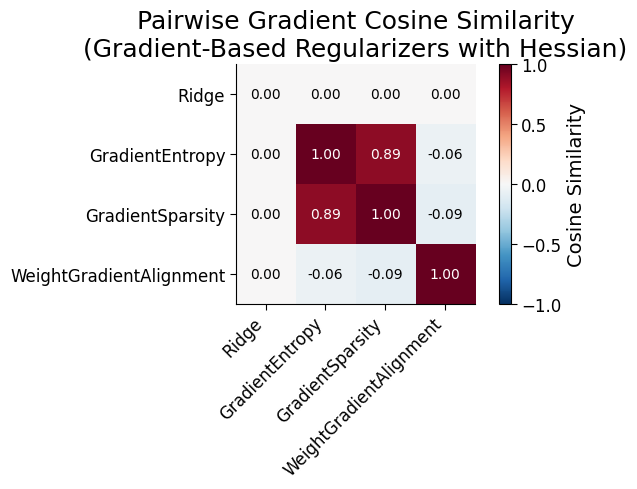

In [18]:
# Pairwise cosine similarity between gradient-based regularizers
# (As true regularizers using second-order gradients)

print("=" * 70)
print("Pairwise Cosine Similarity: Gradient-Based Regularizers")
print("=" * 70)

n_samples = 10
n_regs = len(gradient_regularizers)
pairwise_grad_reg = np.zeros((n_regs, n_regs))

for seed in range(n_samples):
    torch.manual_seed(seed)
    
    net = torch.nn.Sequential(
        torch.nn.Linear(20, 50),
        torch.nn.ReLU(),
        torch.nn.Linear(50, 10),
    )
    
    X = torch.randn(16, 20)
    y = torch.randint(0, 10, (16,))
    
    # Compute gradients for all regularizers
    reg_grads = []
    for name, reg_fn in gradient_regularizers:
        try:
            grad = compute_gradient_regularizer_gradient(net, X, y, reg_fn)
            reg_grads.append(grad)
        except:
            reg_grads.append(None)
    
    # Pairwise cosine similarity
    for i in range(n_regs):
        for j in range(n_regs):
            if reg_grads[i] is not None and reg_grads[j] is not None:
                cos_sim = torch.nn.functional.cosine_similarity(
                    reg_grads[i].unsqueeze(0), reg_grads[j].unsqueeze(0)
                ).item()
                pairwise_grad_reg[i, j] += cos_sim / n_samples

names_gr = [name for name, _ in gradient_regularizers]
df_pairwise_gr = pd.DataFrame(pairwise_grad_reg, index=names_gr, columns=names_gr).round(3)
print(df_pairwise_gr)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pairwise_grad_reg, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(names_gr)))
ax.set_yticks(range(len(names_gr)))
ax.set_xticklabels(names_gr, rotation=45, ha="right")
ax.set_yticklabels(names_gr)
for i in range(len(names_gr)):
    for j in range(len(names_gr)):
        ax.text(j, i, f"{pairwise_grad_reg[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(pairwise_grad_reg[i, j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.title("Pairwise Gradient Cosine Similarity\n(Gradient-Based Regularizers with Hessian)")
plt.tight_layout()
plt.show()
